# Домашнее задание. Нейросетевая классификация текстов

В этом домашнем задании вам предстоит самостоятельно решить задачу классификации текстов на основе семинарского кода. Мы будем использовать датасет [ag_news](https://paperswithcode.com/dataset/ag-news). Это датасет для классификации новостей на 4 темы: "World", "Sports", "Business", "Sci/Tech".

Установим модуль datasets, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

Импорт необходимых библиотек

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import datasets

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set(palette='summer')

import copy

In [8]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных
Для вашего удобства, мы привели код обработки датасета в ноутбуке. Ваша задача --- обучить модель, которая получит максимальное возможное качество на тестовой части.

In [10]:
# Загрузим датасет
dataset = datasets.load_dataset('ag_news')

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [11]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Как и в семинаре, выполним следующие шаги:
* Составим словарь
* Создадим класс WordDataset
* Выделим обучающую и тестовую часть, создадим DataLoader-ы.

In [12]:
words = Counter()
for example in tqdm(dataset['train']['text']):
    # Приводим к нижнему регистру и убираем пунктуацию
    prccessed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(prccessed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 25

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/120000 [00:00<?, ?it/s]

Размер словаря: 11842


In [16]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        processed_text = self.data[idx]['text'].lower().translate(
            str.maketrans('', '', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)
            ]
        tokenized_sentence += [self.eos_id]

        train_sample = {
            "text": tokenized_sentence,
            "label": self.data[idx]['label']
        }

        return train_sample

    def __len__(self) -> int:
        return len(self.data)


def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>'], max_len=256) -> torch.Tensor:
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]
        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])

    sequences = torch.LongTensor(new_batch).to(device)
    labels = torch.LongTensor([x['label'] for x in input_batch]).to(device)

    new_batch = {
        'input_ids': sequences,
        'label': labels
    }

    return new_batch

In [17]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 32
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Постановка задачи
Ваша задача -- получить максимальное возможное accuracy на `eval_dataloader`. Ниже приведена функция, которую вам необходимо запустить для обученной модели, чтобы вычислить качество её работы.

In [18]:
def evaluate(model, eval_dataloader) -> float:
    """
    Calculate accuracy on validation dataloader.
    """

    predictions = []
    target = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'])
            predictions.append(logits.argmax(dim=1))
            target.append(batch['label'])

    predictions = torch.cat(predictions)
    target = torch.cat(target)
    accuracy = (predictions == target).float().mean().item()

    return accuracy

## Ход работы
Оценка за домашнее задание складывается из четырех частей:
### Запуск базовой модели с семинара на новом датасете (1 балл)
На семинаре мы создали модель, которая дает на нашей задаче довольно высокое качество. Ваша цель --- обучить ее и вычислить `score`, который затем можно будет использовать в качестве бейзлайна.

В модели появится одно важное изменение: количество классов теперь равно не 2, а 4. Обратите на это внимание и найдите, что в коде создания модели нужно модифицировать, чтобы учесть это различие.

### Проведение экспериментов по улучшению модели (2 балла за каждый эксперимент)
Чтобы улучшить качество базовой модели, можно попробовать различные идеи экспериментов. Каждый выполненный эксперимент будет оцениваться в 2 балла. Для получения полного балла за этот пункт вам необходимо выполнить по крайней мере 2 эксперимента. Не расстраивайтесь, если какой-то эксперимент не дал вам прироста к качеству: он все равно зачтется, если выполнен корректно.

Вот несколько идей экспериментов:
* **Модель RNN**. Попробуйте другие нейросетевые модели --- LSTM и GRU. Мы советуем обратить внимание на [GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html), так как интерфейс этого класса ничем не отличается от обычной Vanilla RNN, которую мы использовали на семинаре.
* **Увеличение количества рекуррентных слоев модели**. Это можно сделать с помощью параметра `num_layers` в классе `nn.RNN`. В такой модели выходы первой RNN передаются в качестве входов второй RNN и так далее.
* **Изменение архитектуры после применения RNN**. В базовой модели используется агрегация со всех эмбеддингов. Возможно, вы захотите конкатенировать результат агрегации и эмбеддинг с последнего токена.
* **Подбор гиперпараметров и обучение до сходимости**. Возможно, для получения более высокого качества просто необходимо увеличить количество эпох обучения нейросети, а также попробовать различные гиперпараметры: размер словаря, `dropout_rate`, `hidden_dim`.

Обратите внимание, что главное правило проведения экспериментов --- необходимо совершать одно архитектурное изменение в одном эксперименте. Если вы совершите несколько изменений, то будет неясно, какое именно из изменений дало прирост к качеству.

### Получение высокого качества (3 балла)
В конце вашей работы вы должны указать, какая из моделей дала лучший результат, и вывести качество, которое дает лучшая модель, с помощью функции `evaluate`. Ваша модель будет оцениваться по метрике `accuracy` следующим образом:
* $accuracy < 0.9$ --- 0 баллов;
* $0.9 \leqslant accuracy < 0.91$ --- 1 балл;
* $0.91 \leqslant accuracy < 0.915$ --- 2 балла;
* $0.915 \leqslant accuracy$ --- 3 балла.

### Оформление отчета (2 балла)
В конце работы подробно опишите все проведенные эксперименты.
* Укажите, какие из экспериментов принесли улучшение, а какие --- нет.
* Проанализируйте графики сходимости моделей в проведенных экспериментах. Являются ли колебания качества обученных моделей существенными в зависимости от эпохи обучения, или же сходимость стабильная?
* Укажите, какая модель получилась оптимальной.

Желаем удачи!

In [19]:
class Rnn_model(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4
        , num_layers: int = 1, type_of_model: str = "Vanilla",
        bidirectional: bool = False, aggregation_combine: list = ["mean"]
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        if type_of_model == "Vanilla":
            self.rnn = nn.RNN(hidden_dim, hidden_dim, num_layers,  batch_first=True, bidirectional = bidirectional)
        elif type_of_model == "LSTM":
            self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first = True, bidirectional = bidirectional)
        elif type_of_model == "GRU":
            self.rnn = nn.GRU(hidden_dim, hidden_dim,num_layers, batch_first = True, bidirectional = bidirectional)
        else:
            raise ValueError("Invalid Model Type")
            
        if len(aggregation_combine) == 0:
            raise ValueError("aggregation_combine must not be empty")
        
        if any(val not in ["mean", "max", "last"] for val in aggregation_combine):
            raise ValueError("Invalid aggregation_combine type(s)")
        
        num_directions = 2 if bidirectional else 1
        num_aggs = len(aggregation_combine)
        
        linear_in = hidden_dim * num_directions * num_aggs
        self.linear = nn.Linear(linear_in, hidden_dim)
        self.aggregation_combine = aggregation_combine
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        
        aggregations = []
        if 'max' in self.aggregation_combine:
            max_aggregated = output.max(dim=1)[0]
            aggregations.append(max_aggregated)
        
        if 'mean' in self.aggregation_combine:
            mean_aggregated = output.mean(dim=1)
            aggregations.append(mean_aggregated)
        
        if 'last' in self.aggregation_combine:
            last_emb = output[:, -1, :]
            aggregations.append(last_emb)

        if len(aggregations) == 0:
            raise ValueError("No aggregation was selected")
        
        if len(aggregations) == 1:
            output = aggregations[0]
        else:
            output = torch.cat(aggregations, dim=1)

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [71]:
# Стандартное обучение без экспериментов

num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    # Correct num_classes to 4 for the ag_news dataset
    model = Rnn_model(
        hidden_dim=256, vocab_size=len(vocab), num_classes=4, aggregation_combine = [aggregation_type]).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                acc.append(evaluate(model, eval_dataloader))
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max


Training epoch 0:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4:   0%|          | 0/3750 [00:00<?, ?it/s]

Лучшая accuracy для подхода max: 90.88
Лучшая accuracy для подхода mean: 91.08


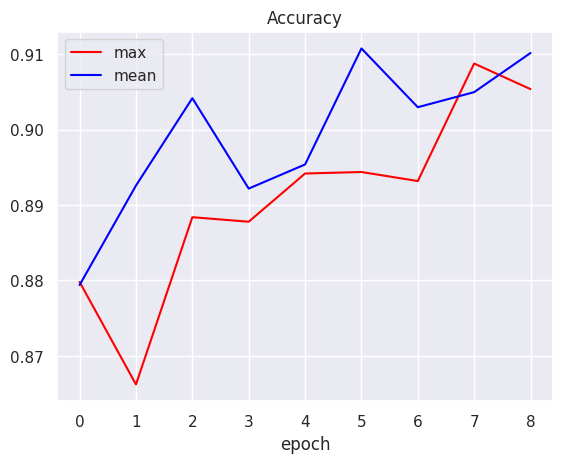

In [72]:
for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
    plt.plot(np.arange(len(acc_type[name][1:])), acc_type[name][1:], color=color, label=name)
    print(f"Лучшая accuracy для подхода {name}: {(max(acc_type[name]) * 100):.2f}")

plt.title('Accuracy')
plt.xlabel("epoch")
plt.legend()
plt.show()

In [73]:
print(f"Accuracy on full_eval: {evaluate(model, eval_dataloader)}")

Accuracy on full_eval: 0.9059999585151672


In [74]:
# Эксперимент: Проверка модели LSTM - передан параметр type_of_model = "LSTM" в класс Rnn_model

num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    # Correct num_classes to 4 for the ag_news dataset
    model = Rnn_model(
        hidden_dim=256, vocab_size=len(vocab), num_classes=4, aggregation_combine = [aggregation_type], type_of_model = "LSTM").to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        print(epoch)
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                acc.append(evaluate(model, eval_dataloader))
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max
0


Training epoch 0:   0%|          | 0/3750 [00:00<?, ?it/s]

1


Training epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

2


...

Training epoch 2:   0%|          | 0/3750 [00:00<?, ?it/s]

3


Training epoch 3:   0%|          | 0/3750 [00:00<?, ?it/s]

4


Training epoch 4:   0%|          | 0/3750 [00:00<?, ?it/s]

Лучшая accuracy для подхода max: 91.16
Лучшая accuracy для подхода mean: 91.64


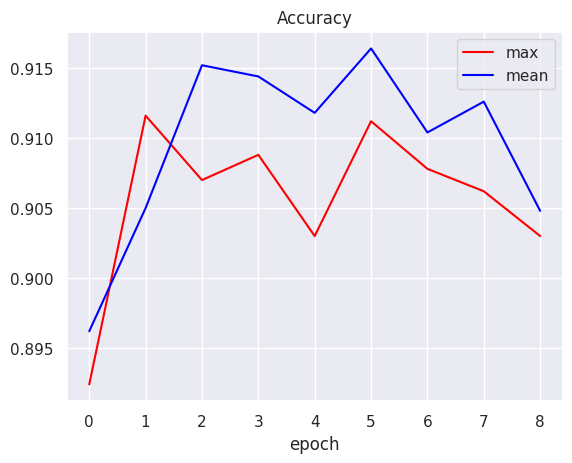

In [75]:
for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
    plt.plot(np.arange(len(acc_type[name][1:])), acc_type[name][1:], color=color, label=name)
    print(f"Лучшая accuracy для подхода {name}: {(max(acc_type[name]) * 100):.2f}")

plt.title('Accuracy')
plt.xlabel("epoch")
plt.legend()
plt.show()

In [77]:
# Эксперимент: Проверка модели GRU - передан параметр type_of_model = "GRU" в класс Rnn_model

num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    # Correct num_classes to 4 for the ag_news dataset
    model = Rnn_model(
        hidden_dim=256, vocab_size=len(vocab), num_classes=4, aggregation_combine = [aggregation_type], type_of_model = "GRU").to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        print(epoch)
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                acc.append(evaluate(model, eval_dataloader))
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max
0


Training epoch 0:   0%|          | 0/3750 [00:00<?, ?it/s]

1


Training epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

2


...

Training epoch 2:   0%|          | 0/3750 [00:00<?, ?it/s]

3


Training epoch 3:   0%|          | 0/3750 [00:00<?, ?it/s]

4


Training epoch 4:   0%|          | 0/3750 [00:00<?, ?it/s]

Лучшая accuracy для подхода max: 91.54
Лучшая accuracy для подхода mean: 91.78


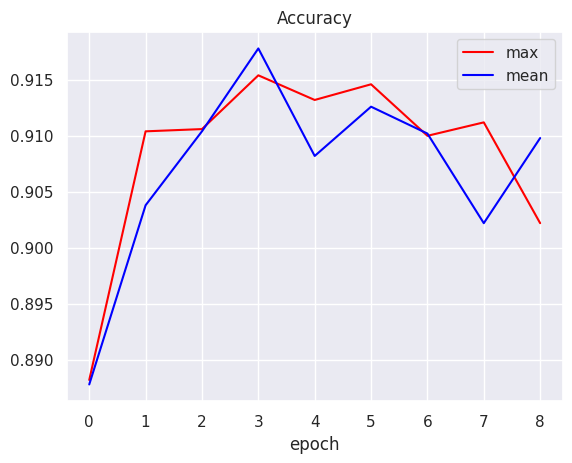

In [78]:
for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
    plt.plot(np.arange(len(acc_type[name][1:])), acc_type[name][1:], color=color, label=name)
    print(f"Лучшая accuracy для подхода {name}: {(max(acc_type[name]) * 100):.2f}")

plt.title('Accuracy')
plt.xlabel("epoch")
plt.legend()
plt.show()

In [98]:
# Эксперимент: Сравнение acc при различном количестве layers с моделью GRU при mean aggregation - передан параметр num_layers
# = num_layers в класс Rnn_model

num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['mean']:
    for num_layers in [1, 2, 3, 4, 5]:
        print(num_layers)
        print(f"Starting training for {aggregation_type}")
        losses = []
        acc = []
    
        # Correct num_classes to 4 for the ag_news dataset
        model = Rnn_model(
            hidden_dim=256, vocab_size=len(vocab), num_classes=4, aggregation_combine = [aggregation_type], num_layers = num_layers, type_of_model = "GRU").to(device)
        criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
        optimizer = torch.optim.Adam(model.parameters())
    
        for epoch in range(num_epoch):
            epoch_losses = []
            model.train()
            for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}')):
                optimizer.zero_grad()
                logits = model(batch['input_ids'])
                loss = criterion(logits, batch['label'])
                loss.backward()
                optimizer.step()
    
                epoch_losses.append(loss.item())
                if i % eval_steps == 0:
                    model.eval()
                    acc.append(evaluate(model, eval_dataloader))
                    model.train()
    
            losses.append(sum(epoch_losses) / len(epoch_losses))
    
        losses_type[num_layers] = losses
        acc_type[num_layers] = acc

1
Starting training for mean


Training epoch 0:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4:   0%|          | 0/3750 [00:00<?, ?it/s]

Лучшая accuracy для num_layers 1: 91.28
Лучшая accuracy для num_layers 2: 91.04
Лучшая accuracy для num_layers 3: 91.28
Лучшая accuracy для num_layers 4: 90.86
Лучшая accuracy для num_layers 5: 90.96


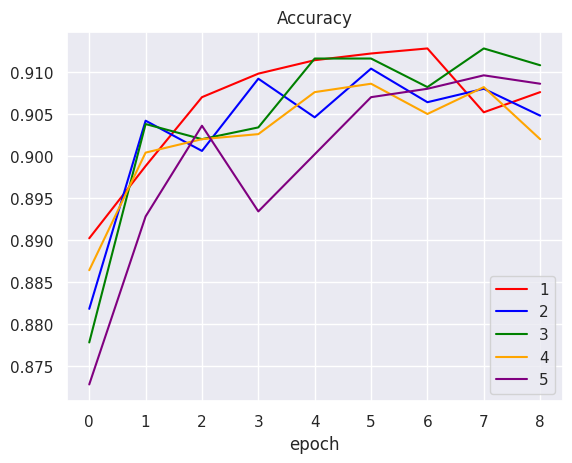

In [99]:
for (num, values), color in zip(losses_type.items(), ['red', 'blue', 'green', 'orange', 'purple']):
    plt.plot(np.arange(len(acc_type[num][1:])), acc_type[num][1:], color=color, label=num)
    print(f"Лучшая accuracy для num_layers {num}: {(max(acc_type[num]) * 100):.2f}")

plt.title('Accuracy')
plt.xlabel("epoch")
plt.legend()
plt.show()

In [21]:
# Эксперимент: Сравнение acc при различном количестве layers с моделью GRU при max aggregation - передан параметр num_layers
# = num_layers в класс Rnn_model

num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['max']:
    for num_layers in [1, 2, 3, 4, 5]:
        print(num_layers)
        print(f"Starting training for {aggregation_type}")
        losses = []
        acc = []
    
        # Correct num_classes to 4 for the ag_news dataset
        model = Rnn_model(
            hidden_dim=256, vocab_size=len(vocab), num_classes=4, aggregation_combine = [aggregation_type], num_layers = num_layers, type_of_model = "GRU").to(device)
        criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
        optimizer = torch.optim.Adam(model.parameters())
    
        for epoch in range(num_epoch):
            epoch_losses = []
            model.train()
            for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}')):
                optimizer.zero_grad()
                logits = model(batch['input_ids'])
                loss = criterion(logits, batch['label'])
                loss.backward()
                optimizer.step()
    
                epoch_losses.append(loss.item())
                if i % eval_steps == 0:
                    model.eval()
                    acc.append(evaluate(model, eval_dataloader))
                    model.train()
    
            losses.append(sum(epoch_losses) / len(epoch_losses))
    
        losses_type[num_layers] = losses
        acc_type[num_layers] = acc

1
Starting training for max


Training epoch 0:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4:   0%|          | 0/3750 [00:00<?, ?it/s]

Лучшая accuracy для num_layers 1: 91.86
Лучшая accuracy для num_layers 2: 91.30
Лучшая accuracy для num_layers 3: 91.14
Лучшая accuracy для num_layers 4: 91.40
Лучшая accuracy для num_layers 5: 91.08


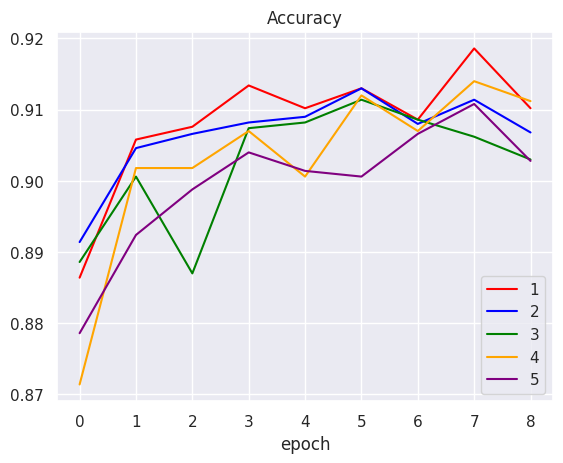

In [22]:
for (num, values), color in zip(losses_type.items(), ['red', 'blue', 'green', 'orange', 'purple']):
    plt.plot(np.arange(len(acc_type[num][1:])), acc_type[num][1:], color=color, label=num)
    print(f"Лучшая accuracy для num_layers {num}: {(max(acc_type[num]) * 100):.2f}")

plt.title('Accuracy')
plt.xlabel("epoch")
plt.legend()
plt.show()

In [95]:
# Эксперимент:  Объединение агрегационного эмбединга и последнего выданного эмбединга 
# Передан параметр combine_last = True в класс Rnn_model

num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in [["max"], ["mean"], ["last"], ['max', 'mean'], ['max', 'last'], ['mean', 'last'], ['max', 'mean', 'last']]:
    print(aggregation_type)
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    # Correct num_classes to 4 for the ag_news dataset
    model = Rnn_model(
        hidden_dim=256, vocab_size=len(vocab), num_classes=4, aggregation_combine = [*aggregation_type], type_of_model = "GRU", num_layers = 2).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                acc.append(evaluate(model, eval_dataloader))
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))
    
    losses_type["_".join(aggregation_type)] = losses
    acc_type["_".join(aggregation_type)] = acc

['max']
Starting training for ['max']


Training epoch 0:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4:   0%|          | 0/3750 [00:00<?, ?it/s]

Лучшая accuracy для подхода max: 91.76
Лучшая accuracy для подхода mean: 90.96
Лучшая accuracy для подхода last: 91.26
Лучшая accuracy для подхода max_mean: 91.32
Лучшая accuracy для подхода max_last: 91.68
Лучшая accuracy для подхода mean_last: 91.52
Лучшая accuracy для подхода max_mean_last: 91.10


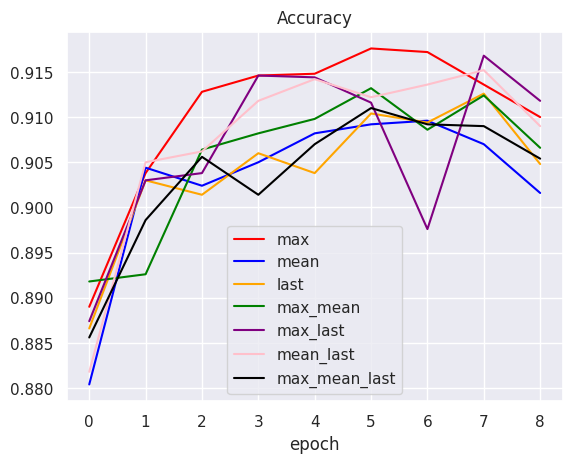

In [96]:
for (name, values), color in zip(losses_type.items(), ['red', 'blue', 'orange', 'green', 'purple', 'pink', 'black']):
    plt.plot(np.arange(len(acc_type[name][1:])), acc_type[name][1:], color=color, label=name)
    print(f"Лучшая accuracy для подхода {name}: {(max(acc_type[name]) * 100):.2f}")

plt.title('Accuracy')
plt.xlabel("epoch")
plt.legend()
plt.show()

In [23]:
# Эксперимент: Сделать слои в Rnn bidirectional
# Передан параметр bidirectional = True в класс Rnn_model

num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['max']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    # Correct num_classes to 4 for the ag_news dataset
    model = Rnn_model(
        hidden_dim=256, vocab_size=len(vocab), num_classes=4, aggregation_combine = [aggregation_type], bidirectional = True,
        type_of_model = "GRU", num_layers = 1).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                acc.append(evaluate(model, eval_dataloader))
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))
    
    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max


Training epoch 0:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4:   0%|          | 0/3750 [00:00<?, ?it/s]

Лучшая accuracy для подхода max: 91.66


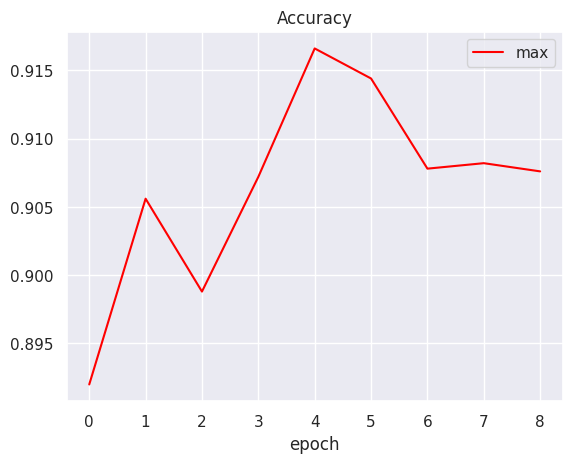

In [24]:
for (name, values), color in zip(losses_type.items(), ['red']):
    plt.plot(np.arange(len(acc_type[name][1:])), acc_type[name][1:], color=color, label=name)
    print(f"Лучшая accuracy для подхода {name}: {(max(acc_type[name]) * 100):.2f}")

plt.title('Accuracy')
plt.xlabel("epoch")
plt.legend()
plt.show()

In [32]:
# Эксперимент: Лучшее количество эпох и запоминание лучшей модели
# Используется лучшая модель - GRU с num_layers = 1, max aggregation, bidirectional = True

num_epoch = 10
eval_steps = len(train_dataloader) // 2
best_acc = 0


losses_type = {}
acc_type = {}

for aggregation_type in ['max']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    # Correct num_classes to 4 for the ag_news dataset
    model = Rnn_model(
        hidden_dim=256, vocab_size=len(vocab), num_classes=4, aggregation_combine = [aggregation_type],
        type_of_model = 'GRU', num_layers = 1, bidirectional = True).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                accur = evaluate(model, eval_dataloader)
                if best_acc < accur:
                    best_acc = accur
                    best_state = copy.deepcopy(model.state_dict())
                    torch.save(best_state, "best_model.pt")
                    print(f"Saved new best model with acc={best_acc:.4f}")
                acc.append(accur)
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))
    
    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max


Training epoch 0:   0%|          | 0/3750 [00:00<?, ?it/s]

Saved new best model with acc=0.2578
Saved new best model with acc=0.8848


Training epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

Saved new best model with acc=0.9068
Saved new best model with acc=0.9074


...

Training epoch 5:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 6:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 7:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 8:   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 9:   0%|          | 0/3750 [00:00<?, ?it/s]

Лучшая accuracy для подхода max: 91.72


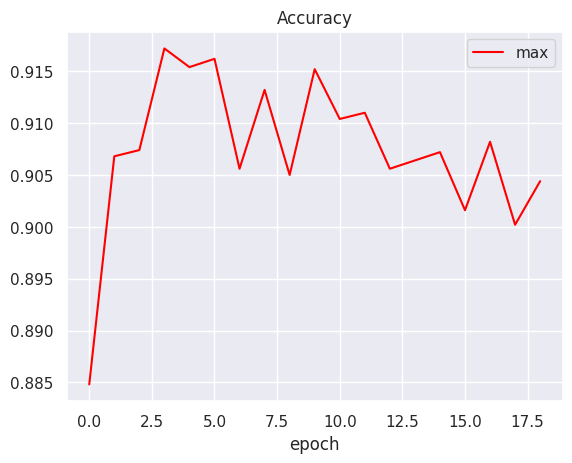

In [33]:
for (name, values), color in zip(losses_type.items(), ['red']):
    plt.plot(np.arange(len(acc_type[name][1:])), acc_type[name][1:], color=color, label=name)
    print(f"Лучшая accuracy для подхода {name}: {(max(acc_type[name]) * 100):.2f}")

plt.title('Accuracy')
plt.xlabel("epoch")
plt.legend()
plt.show()

In [34]:
best_model = Rnn_model(
    hidden_dim=256,
    vocab_size=len(vocab),
    num_classes=4,
    aggregation_combine=[aggregation_type],
    type_of_model='GRU',
    num_layers=1,
    bidirectional=True
).to(device)

best_model.load_state_dict(torch.load("best_model.pt", map_location=device))
best_model.eval()
print(f"Accuracy: {evaluate(best_model, eval_dataloader)}")

Accuracy: 0.917199969291687


В данной работе была решена задача многоклассовой классификации текстов на датасете **AG News**. В качестве основы была взята рекуррентная модель из семинарского кода, адаптированная под задачу классификации на **4 класса**. После запуска базовой версии была проведена серия экспериментов, направленных на улучшение качества модели.

При интерпретации результатов важно учитывать, что значения `accuracy` в этой задаче могут заметно меняться от запуска к запуску. Это связано со случайной инициализацией весов, перемешиванием обучающей выборки, стохастичностью оптимизации и выбором подмножества данных для оценки. Поэтому отдельный численный результат нельзя считать абсолютно фиксированным: корректнее анализировать не только конкретное значение метрики, но и общее поведение модели, устойчивость обучения и среднюю тенденцию по экспериментам.

## Базовая модель

В качестве бейзлайна была обучена стандартная `Vanilla RNN`. В модели было исправлено число выходных классов: вместо бинарной классификации использовалась классификация на 4 категории. Также были проверены два способа агрегации скрытых состояний:
- `max aggregation`;
- `mean aggregation`.

Базовая модель показала хорошее стартовое качество и подтвердила, что сама архитектура рекуррентной сети уже подходит для решения задачи. При этом качество зависело от способа агрегации, что показало важность выбора представления последовательности после прохождения через RNN.

## Проведенные эксперименты

### 1. Замена Vanilla RNN на LSTM

Первым экспериментом стала замена обычной рекуррентной сети на `LSTM`. Эта архитектура лучше работает с долгосрочными зависимостями в последовательностях, поскольку использует механизм памяти и управляющие ворота.

Для `LSTM` были протестированы те же варианты агрегации, что и в базовой модели. По результатам запусков можно сделать вывод, что `LSTM` в целом обучалась стабильно и обычно не ухудшала качество по сравнению с базовой `Vanilla RNN`. Это говорит о том, что более сложная рекуррентная архитектура действительно лучше подходит для текстовой классификации, где важен контекст по всей длине текста.

### 2. Замена Vanilla RNN на GRU

Следующим экспериментом стала замена базовой сети на `GRU`. Эта архитектура по смыслу близка к `LSTM`, но имеет более простую внутреннюю структуру и обычно обучается немного быстрее.

По результатам запусков `GRU` показала себя очень хорошо: качество было высоким и устойчивым, а сама модель сходилась достаточно стабильно. Визуально по графикам видно, что обучение происходило без резких провалов, а метрика достаточно быстро выходила на плато. Это позволяет считать `GRU` удачным вариантом для данной задачи.

### 3. Изменение числа рекуррентных слоев

После выбора `GRU` было проверено влияние параметра `num_layers`, то есть количества рекуррентных слоев. Проверялись более глубокие варианты модели, в которых выход одной рекуррентной сети подается на вход следующей.

Идея эксперимента состояла в том, что дополнительные слои могли бы помочь модели извлекать более сложные признаки из текста. Однако на практике заметного устойчивого улучшения это не дало. В разных запусках результаты колебались, но общей тенденции к уверенному росту качества при увеличении числа слоев не наблюдалось. Более глубокие модели оказывались сложнее, обучались дольше, но не демонстрировали явного преимущества перед более простой конфигурацией.

Из этого можно сделать вывод, что для данной задачи чрезмерное усложнение рекуррентной части не обязательно полезно: текстовая классификация AG News достаточно хорошо решается и относительно простой архитектурой.

### 4. Исследование способов агрегации

Отдельно была исследована роль агрегации скрытых состояний. Были рассмотрены следующие варианты:
- использование только `max aggregation`;
- использование только `mean aggregation`;
- использование только последнего скрытого состояния `last`;
- комбинации нескольких вариантов, например `max + mean`, `max + last`, `mean + last`, а также объединение всех трех способов.

Этот эксперимент был важен, потому что после прохождения текста через рекуррентную сеть нужно получить единый вектор признаков для классификации. Разные способы агрегации по-разному собирают информацию о последовательности:
- `mean` усредняет признаки по всей последовательности;
- `max` выбирает наиболее выраженные признаки;
- `last` опирается на последнее скрытое состояние как итоговое представление текста.

По результатам эксперимента можно сказать, что комбинации агрегаций не дали устойчивого преимущества. Иногда отдельные запуски показывали хороший результат, но в целом усложнение схемы агрегации не приводило к гарантированному росту качества. Это означает, что для данной задачи достаточно простой стратегии агрегации, а добавление новых компонентов не обязательно делает представление текста лучше.

### 5. Bidirectional GRU

Следующим экспериментом стала двунаправленная `GRU`, то есть модель, которая обрабатывает текст одновременно слева направо и справа налево. Такой подход позволяет учитывать контекст не только из начала предложения к концу, но и в обратную сторону.

Этот эксперимент оказался особенно интересным. Хотя из-за случайности обучения численные результаты менялись между запусками, `bidirectional`-конфигурация в среднем показывала хорошее качество и выглядела достаточно надежной. Именно поэтому в качестве итоговой модели была выбрана **bidirectional GRU**: не потому, что в одном конкретном запуске она обязательно дает абсолютный максимум, а потому что она демонстрирует сильный и качественный результат в целом и хорошо соответствует идее более полного учета контекста в тексте.

### 6. Увеличение числа эпох и сохранение лучшей модели

После выбора итоговой архитектуры было проведено дополнительное обучение в течение большего числа эпох с сохранением лучшего состояния модели по `accuracy` на валидации. Это позволило не просто посмотреть на финальную эпоху, а зафиксировать наиболее удачное состояние сети в процессе обучения.

Такой подход является более корректным, чем использование только модели с последней эпохи, потому что качество может немного колебаться в ходе обучения. Сохранение лучшего состояния помогает уменьшить влияние этих колебаний и выбрать наиболее удачную версию модели из конкретного запуска.

## Анализ сходимости моделей

По графикам сходимости видно, что обучение в целом происходило стабильно. На первых эпохах качество росло достаточно быстро, после чего выходило на плато. Существенных признаков развала обучения или сильной нестабильности не наблюдалось.

При этом небольшие колебания метрики между измерениями являются нормальными и ожидаемыми. Они не означают, что модель работает плохо, а скорее отражают стохастическую природу обучения нейросетей. Поэтому при сравнении экспериментов важно смотреть не только на одну конкретную точку или один запуск, а на общую тенденцию:
- помогает ли архитектурное изменение модели в среднем;
- становится ли обучение более стабильным;
- выглядит ли результат воспроизводимым на повторных запусках.

С этой точки зрения `GRU` и особенно `bidirectional GRU` показали себя хорошо.

## Итоговая модель и финальный результат

В качестве итоговой модели была выбрана **bidirectional GRU**. Такой выбор сделан с учетом того, что результаты экспериментов зависят от случайности запуска, а двунаправленная архитектура в среднем показывает хорошее качество и использует контекст последовательности более полно.

Финальная сохраненная модель показала:
- `Accuracy = 0.9172`

Этот результат можно считать высоким для данной постановки задачи. Он показывает, что подобранная архитектура успешно решает задачу классификации новостей и уверенно различает четыре тематических класса.

## Вывод

В ходе работы была реализована и обучена базовая рекуррентная модель для классификации текстов, а затем проведен ряд экспериментов по ее улучшению. Были исследованы разные типы рекуррентных слоев (`Vanilla RNN`, `LSTM`, `GRU`), количество слоев, способы агрегации скрытых состояний, а также двунаправленная архитектура.

Эксперименты показали, что качество модели зависит не только от архитектуры, но и от случайности конкретного запуска, поэтому сравнение необходимо проводить аккуратно. Наиболее разумной итоговой конфигурацией оказалась **bidirectional GRU**, так как она в среднем демонстрировала хорошую `accuracy`, стабильное обучение и логично использовала информацию о контексте в обе стороны.

Таким образом, можно сделать вывод, что для задачи классификации новостей рекуррентные архитектуры семейства `GRU` являются эффективным решением, а двунаправленная версия модели дает сильный итоговый результат и хорошо подходит в качестве финальной модели.